In [1]:
from itertools import accumulate
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from sklearn.metrics import RocCurveDisplay
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import confusion_matrix_at_thresholds

In [2]:
exploration = 'ppca_16'
dataset_dir = Path('datasets')
results_dir = Path('results') / exploration
naive_dir = results_dir.parent / 'naive_00'

## Dataset exploration

In [3]:
train_data = np.load(dataset_dir / 'pav_features/train_split.npy')
valid_data = np.load(dataset_dir / 'pav_features/valid_split.npy')

train_total_defec = train_data[:, -1].sum()
train_total_clean = train_data.shape[0] - train_total_defec
train_prop = train_total_defec / train_data.shape[0]

valid_total_defec = valid_data[:, -1].sum()
valid_total_clean = valid_data.shape[0] - valid_total_defec
valid_prop = valid_total_defec / valid_data.shape[0]

print(
    'Treino    : %04d com defeito, %04d sem defeito [%5.2f%%]'
    %(train_total_defec, train_total_clean, train_prop * 100)
)
print(
    'Validação : %04d com defeito, %04d sem defeito [%5.2f%%]'
    %(valid_total_defec, valid_total_clean, valid_prop * 100)
)

Treino    : 0441 com defeito, 4312 sem defeito [ 9.28%]
Validação : 0193 com defeito, 1799 sem defeito [ 9.69%]


## PPCA

In [4]:
iterations = sorted(list(results_dir.glob('iteration_*')))
exp_defec_images = []
exp_clean_images = []
naive_defec_counts = []
naive_clean_counts = []
train_evals = []
valid_evals = []
for iteration in iterations:
    train_eval = np.load(iteration / 'train.npy')
    valid_eval = np.load(iteration / 'valid.npy')
    train_evals.append(train_eval)
    valid_evals.append(valid_eval)
    with (iteration / 'clean_images.txt').open('r') as f:
        exp_clean_images.append(f.read().splitlines())
    with (iteration / 'defec_images.txt').open('r') as f:
        exp_defec_images.append(f.read().splitlines())
    with (naive_dir / iteration.name / 'clean_images.txt').open('r') as f:
        naive_clean_counts.append(len(f.read().splitlines()))
    with (naive_dir / iteration.name / 'defec_images.txt').open('r') as f:
        naive_defec_counts.append(len(f.read().splitlines()))

### Resumo
Resumo dos subconjuntos encontrados durante a exploração.

In [5]:
exp_clean_counts = [len(imgs) for imgs in exp_clean_images[:-1]]
exp_defec_counts = [len(imgs) for imgs in exp_defec_images[:-1]]
exp_total_clean = sum(exp_clean_counts)
exp_total_defec = sum(exp_defec_counts)

naive_clean_counts = naive_clean_counts[:-1]
naive_defec_counts = naive_defec_counts[:-1]
naive_total_clean = sum(naive_clean_counts)
naive_total_defec = sum(naive_defec_counts)

print(
    '%s : %4d com defeitos, %4d sem defeitos [%5.2f%%]'
    %(
        'Conjunto total'.ljust(21),
        train_total_defec,
        train_total_clean,
        train_prop * 100,
    )
)
print(
    '%s : %4d com defeitos, %4d sem defeitos [%5.2f%%]'
    %(
        'Subconjunto randômico'.ljust(21),
        naive_total_defec,
        naive_total_clean,
        naive_total_defec / (naive_total_defec + naive_total_clean) * 100,
    )
)
print(
    '%s : %4d com defeitos, %4d sem defeitos [%5.2f%%]'
    %(
        f'Subconjunto {exploration}'.ljust(21),
        exp_total_defec,
        exp_total_clean,
        exp_total_defec / (exp_total_defec + exp_total_clean) * 100,
    )
)
print(
    '%s encontrou %.2f%% das imagens com defeitos.'
    %(exploration, exp_total_defec / train_total_defec * 100)
)

Conjunto total        :  441 com defeitos, 4312 sem defeitos [ 9.28%]
Subconjunto randômico :   99 com defeitos,  901 sem defeitos [ 9.90%]
Subconjunto ppca_16   :  183 com defeitos,  817 sem defeitos [18.30%]
ppca_16 encontrou 41.50% das imagens com defeitos.


### Contagem de imagens encontradas
A expectativa é que o número de imagens com defeitos supere os valores esperados em cada nova seleção de imagens, uma vez que as imagens selecionadas são aquelas com as menores probabilidade segundo a distribuição marginal das imagens sem defeitos, que é o que se espera de imagens com defeitos.

In [6]:
def get_expected_count(
    clean_counts,
    defec_counts,
    total_clean,
    total_defec,
    selection_size=50,
):
    num_iterations = len(clean_counts)
    clean_expected_counts = []
    defec_expected_counts = []
    for i in range(num_iterations):
        total = total_clean + total_defec
        clean_expected_counts.append(selection_size * total_clean / total)
        defec_expected_counts.append(selection_size * total_defec / total)
        total_clean -= clean_counts[i]
        total_defec -= defec_counts[i]
    return clean_expected_counts, defec_expected_counts

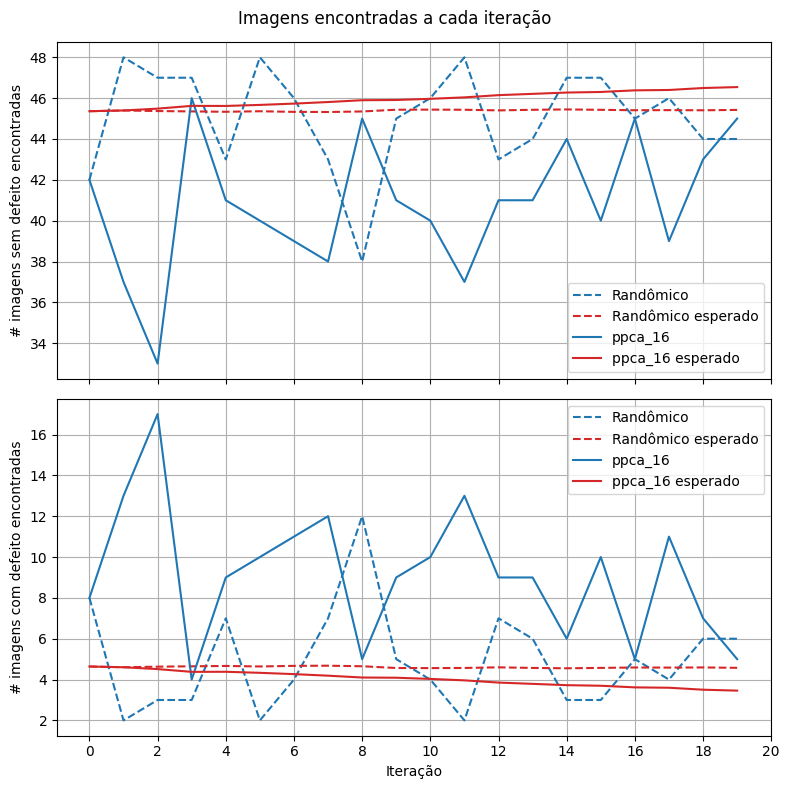

In [7]:
naive_expected_clean_counts, naive_expected_defec_counts = get_expected_count(
    naive_clean_counts, naive_defec_counts, train_total_clean, train_total_defec
)
exp_expected_clean_counts, exp_expected_defec_counts = get_expected_count(
    exp_clean_counts, exp_defec_counts, train_total_clean, train_total_defec
)

fig, (cl_count, df_count) = plt.subplots(2, 1, figsize=(8, 8), sharex=True)
# Imagens sem defeito
cl_count.plot(naive_clean_counts, color='tab:blue', ls='--', label='Randômico')
cl_count.plot(naive_expected_clean_counts, color='tab:red', ls='--', label='Randômico esperado')
cl_count.plot(exp_clean_counts, color='tab:blue', label=exploration)
cl_count.plot(exp_expected_clean_counts, color='tab:red', label=f'{exploration} esperado')
cl_count.set_ylabel('# imagens sem defeito encontradas')
cl_count.grid(True)
cl_count.legend()
# Imagens com defeito
df_count.plot(naive_defec_counts, color='tab:blue', ls='--', label='Randômico')
df_count.plot(naive_expected_defec_counts, color='tab:red', ls='--', label='Randômico esperado')
df_count.plot(exp_defec_counts, color='tab:blue', label=exploration)
df_count.plot(exp_expected_defec_counts, color='tab:red', label=f'{exploration} esperado')
df_count.set_xlabel('Iteração')
df_count.set_xticks(range(0, len(exp_defec_counts) + 1, 2))
df_count.set_ylabel('# imagens com defeito encontradas')
df_count.grid(True)
df_count.legend()

fig.suptitle('Imagens encontradas a cada iteração')
plt.tight_layout()
plt.show()

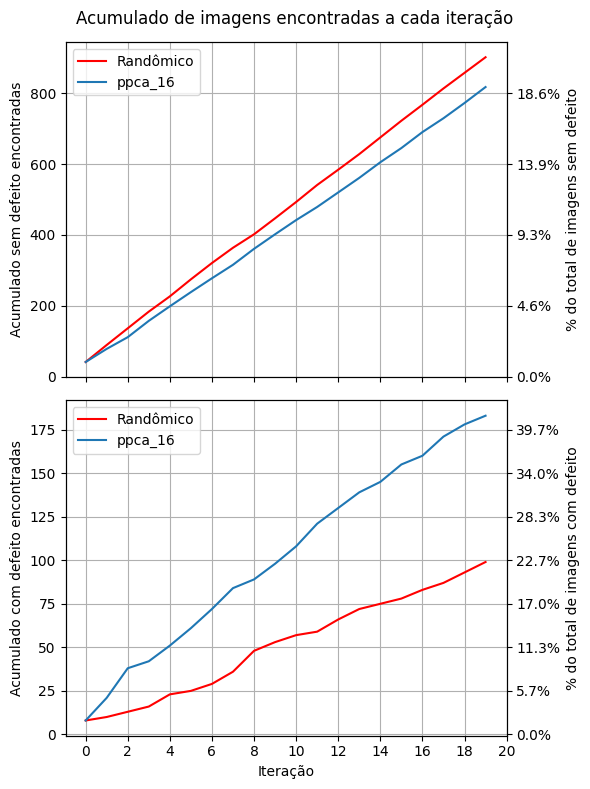

In [8]:
naive_clean_accumu = list(accumulate(naive_clean_counts))
naive_defec_accumu = list(accumulate(naive_defec_counts))
exp_clean_accumu = list(accumulate(exp_clean_counts))
exp_defec_accumu = list(accumulate(exp_defec_counts))

fig, (cl_accum, lk_trunc) = plt.subplots(2, 1, figsize=(6, 8), sharex=True)
# Imagens sem defeito acumuladas
cl_accum.plot(naive_clean_accumu, c='red', label='Randômico')
cl_accum.plot(exp_clean_accumu, label=exploration)
cl_accum.set_ylabel('Acumulado sem defeito encontradas')
cl_accum.grid(True)
cl_accum.legend()
cl_rc_accum = cl_accum.twinx()
cl_rc_accum.set_ylim(cl_accum.get_ylim())
formatter = mticker.PercentFormatter(xmax=train_total_clean)
cl_rc_accum.yaxis.set_major_formatter(formatter)
cl_rc_accum.set_ylabel('% do total de imagens sem defeito')
# Imagens com defeito acumuladas
lk_trunc.plot(naive_defec_accumu, c='red', label='Randômico')
lk_trunc.plot(exp_defec_accumu, label=exploration)
lk_trunc.set_ylabel('Acumulado com defeito encontradas')
lk_trunc.set_xlabel('Iteração')
lk_trunc.set_xticks(range(0, len(exp_defec_counts) + 1, 2))
lk_trunc.grid(True)
lk_trunc.legend()
df_rc_accum = lk_trunc.twinx()
df_rc_accum.set_ylim(lk_trunc.get_ylim())
formatter = mticker.PercentFormatter(xmax=train_total_defec)
df_rc_accum.yaxis.set_major_formatter(formatter)
df_rc_accum.set_ylabel('% do total de imagens com defeito')

fig.suptitle('Acumulado de imagens encontradas a cada iteração')
plt.tight_layout()
plt.show()

### Log-verossimilhança

Com o passar das iterações e novas imagens sem defeitos surgem, a expectativa é que a estimação de densidade das imagens sem defeitos melhore. Espera-se que a log-verossimilhança média das imagens sem defeitos presentes no conjunto de validação aumente com o passar das iterações e que a log-verossimilhança média das imagens com defeitos diminua.

In [9]:
train_clean_loglike = []
train_defec_loglike = []
valid_clean_loglike = []
valid_defec_loglike = []
train_defec_mask = train_data[:, -1].astype(bool)
valid_defec_mask = valid_data[:, -1].astype(bool)
for i in range(len(train_evals)):
    train_defec_loglike.append(train_evals[i][train_defec_mask, -1])
    train_clean_loglike.append(train_evals[i][~train_defec_mask, -1])
    valid_defec_loglike.append(valid_evals[i][valid_defec_mask, -1])
    valid_clean_loglike.append(valid_evals[i][~valid_defec_mask, -1])

train_clean_points = [(clk.min(), clk.mean(), clk.max()) for clk in train_clean_loglike]
train_defec_points = [(clk.min(), clk.mean(), clk.max()) for clk in train_defec_loglike]
valid_clean_points = [(clk.min(), clk.mean(), clk.max()) for clk in valid_clean_loglike]
valid_defec_points = [(clk.min(), clk.mean(), clk.max()) for clk in valid_defec_loglike]

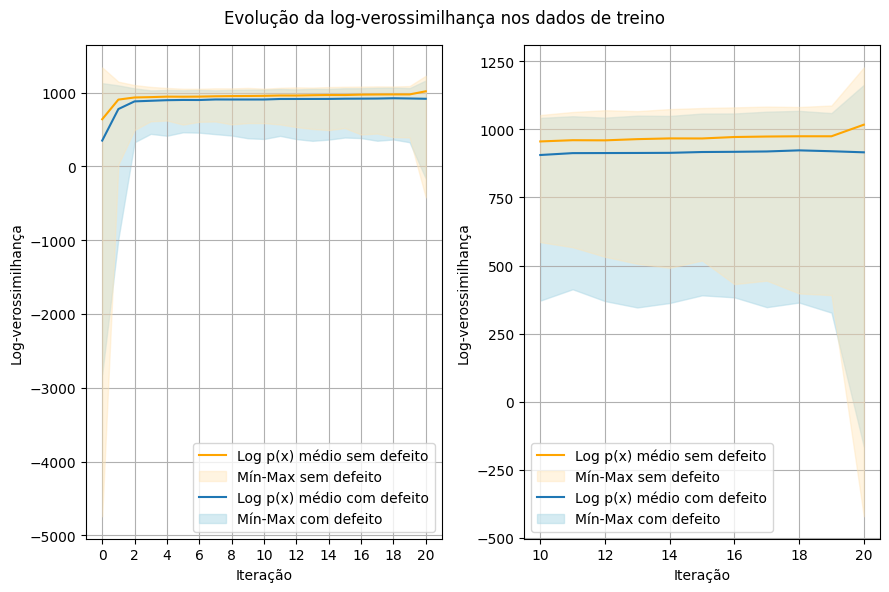

In [10]:
fig, (train_lk_whole, train_lk_trunc) = plt.subplots(1, 2, figsize=(9, 6))

train_lk_whole.plot(
    [clk[1] for clk in train_clean_points],
    color='orange',
    label='Log p(x) médio sem defeito',
    zorder=3,
)
train_lk_whole.fill_between(
    x=range(len(train_evals)),
    y1=[clk[0] for clk in train_clean_points],
    y2=[clk[2] for clk in train_clean_points],
    alpha=0.4,
    color='moccasin',
    label='Mín-Max sem defeito',
    zorder=2,
)
train_lk_whole.plot(
    [clk[1] for clk in train_defec_points],
    color='tab:blue',
    label='Log p(x) médio com defeito',
    zorder=3,
)
train_lk_whole.fill_between(
    x=range(len(train_evals)),
    y1=[clk[0] for clk in train_defec_points],
    y2=[clk[2] for clk in train_defec_points],
    alpha=0.5,
    color='lightblue',
    label='Mín-Max com defeito',
    zorder=1,
)
train_lk_whole.set_xlabel('Iteração')
train_lk_whole.set_ylabel('Log-verossimilhança')
train_lk_whole.set_xticks(range(0, len(train_evals) + 1, 2))
train_lk_whole.grid(True)
train_lk_whole.legend()
mid_iteration = len(train_evals) // 2
train_lk_trunc.plot(
    range(mid_iteration, len(train_evals)),
    [clk[1] for clk in train_clean_points[mid_iteration:]],
    color='orange',
    label='Log p(x) médio sem defeito',
    zorder=3,
)
train_lk_trunc.fill_between(
    x=range(mid_iteration, len(train_evals)),
    y1=[clk[0] for clk in train_clean_points[mid_iteration:]],
    y2=[clk[2] for clk in train_clean_points[mid_iteration:]],
    alpha=0.4,
    color='moccasin',
    label='Mín-Max sem defeito',
    zorder=2,
)
train_lk_trunc.plot(
    range(mid_iteration, len(train_evals)),
    [clk[1] for clk in train_defec_points[mid_iteration:]],
    color='tab:blue',
    label='Log p(x) médio com defeito',
    zorder=3,
)
train_lk_trunc.fill_between(
    x=range(mid_iteration, len(train_evals)),
    y1=[clk[0] for clk in train_defec_points[mid_iteration:]],
    y2=[clk[2] for clk in train_defec_points[mid_iteration:]],
    alpha=0.5,
    color='lightblue',
    label='Mín-Max com defeito',
    zorder=1,
)
train_lk_trunc.set_xlabel('Iteração')
train_lk_trunc.set_ylabel('Log-verossimilhança')
train_lk_trunc.set_xticks(range(mid_iteration, len(train_evals) + 1, 2))
train_lk_trunc.grid(True)
train_lk_trunc.legend()

fig.suptitle('Evolução da log-verossimilhança nos dados de treino')
plt.tight_layout()
plt.show()

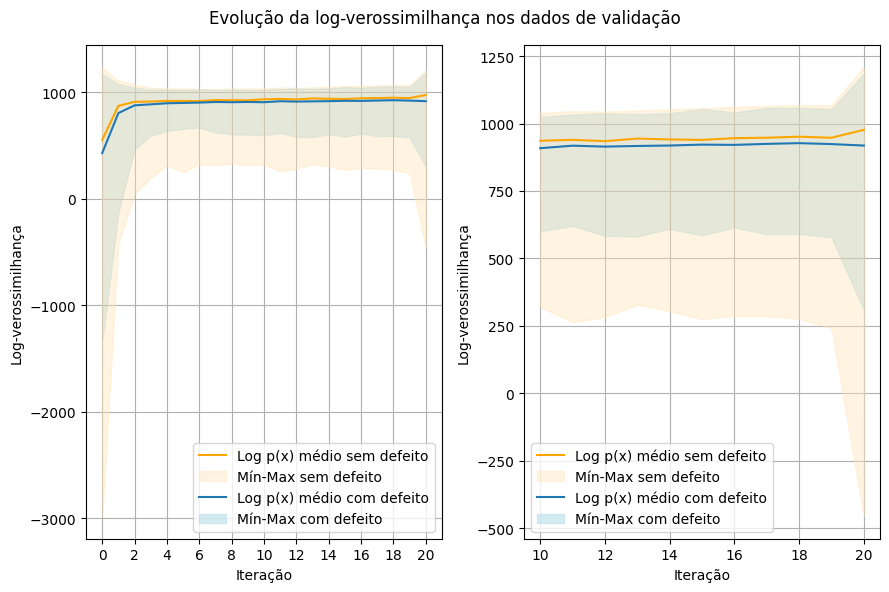

In [11]:
fig, (valid_lk_whole, valid_lk_trunc) = plt.subplots(1, 2, figsize=(9, 6))

valid_lk_whole.plot(
    [clk[1] for clk in valid_clean_points],
    color='orange',
    label='Log p(x) médio sem defeito',
    zorder=3,
)
valid_lk_whole.fill_between(
    x=range(len(valid_evals)),
    y1=[clk[0] for clk in valid_clean_points],
    y2=[clk[2] for clk in valid_clean_points],
    alpha=0.4,
    color='moccasin',
    label='Mín-Max sem defeito',
    zorder=2,
)
valid_lk_whole.plot(
    [clk[1] for clk in valid_defec_points],
    color='tab:blue',
    label='Log p(x) médio com defeito',
    zorder=3,
)
valid_lk_whole.fill_between(
    x=range(len(valid_evals)),
    y1=[clk[0] for clk in valid_defec_points],
    y2=[clk[2] for clk in valid_defec_points],
    alpha=0.5,
    color='lightblue',
    label='Mín-Max com defeito',
    zorder=1,
)
valid_lk_whole.set_xlabel('Iteração')
valid_lk_whole.set_ylabel('Log-verossimilhança')
valid_lk_whole.set_xticks(range(0, len(valid_evals) + 1, 2))
valid_lk_whole.grid(True)
valid_lk_whole.legend()
mid_iteration = len(valid_evals) // 2
valid_lk_trunc.plot(
    range(mid_iteration, len(valid_evals)),
    [clk[1] for clk in valid_clean_points[mid_iteration:]],
    color='orange',
    label='Log p(x) médio sem defeito',
    zorder=3,
)
valid_lk_trunc.fill_between(
    x=range(mid_iteration, len(valid_evals)),
    y1=[clk[0] for clk in valid_clean_points[mid_iteration:]],
    y2=[clk[2] for clk in valid_clean_points[mid_iteration:]],
    alpha=0.4,
    color='moccasin',
    label='Mín-Max sem defeito',
    zorder=2,
)
valid_lk_trunc.plot(
    range(mid_iteration, len(valid_evals)),
    [clk[1] for clk in valid_defec_points[mid_iteration:]],
    color='tab:blue',
    label='Log p(x) médio com defeito',
    zorder=3,
)
valid_lk_trunc.fill_between(
    x=range(mid_iteration, len(valid_evals)),
    y1=[clk[0] for clk in valid_defec_points[mid_iteration:]],
    y2=[clk[2] for clk in valid_defec_points[mid_iteration:]],
    alpha=0.5,
    color='lightblue',
    label='Mín-Max com defeito',
    zorder=1,
)
valid_lk_trunc.set_xlabel('Iteração')
valid_lk_trunc.set_ylabel('Log-verossimilhança')
valid_lk_trunc.set_xticks(range(mid_iteration, len(valid_evals) + 1, 2))
valid_lk_trunc.grid(True)
valid_lk_trunc.legend()

fig.suptitle('Evolução da log-verossimilhança nos dados de validação')
plt.tight_layout()
plt.show()

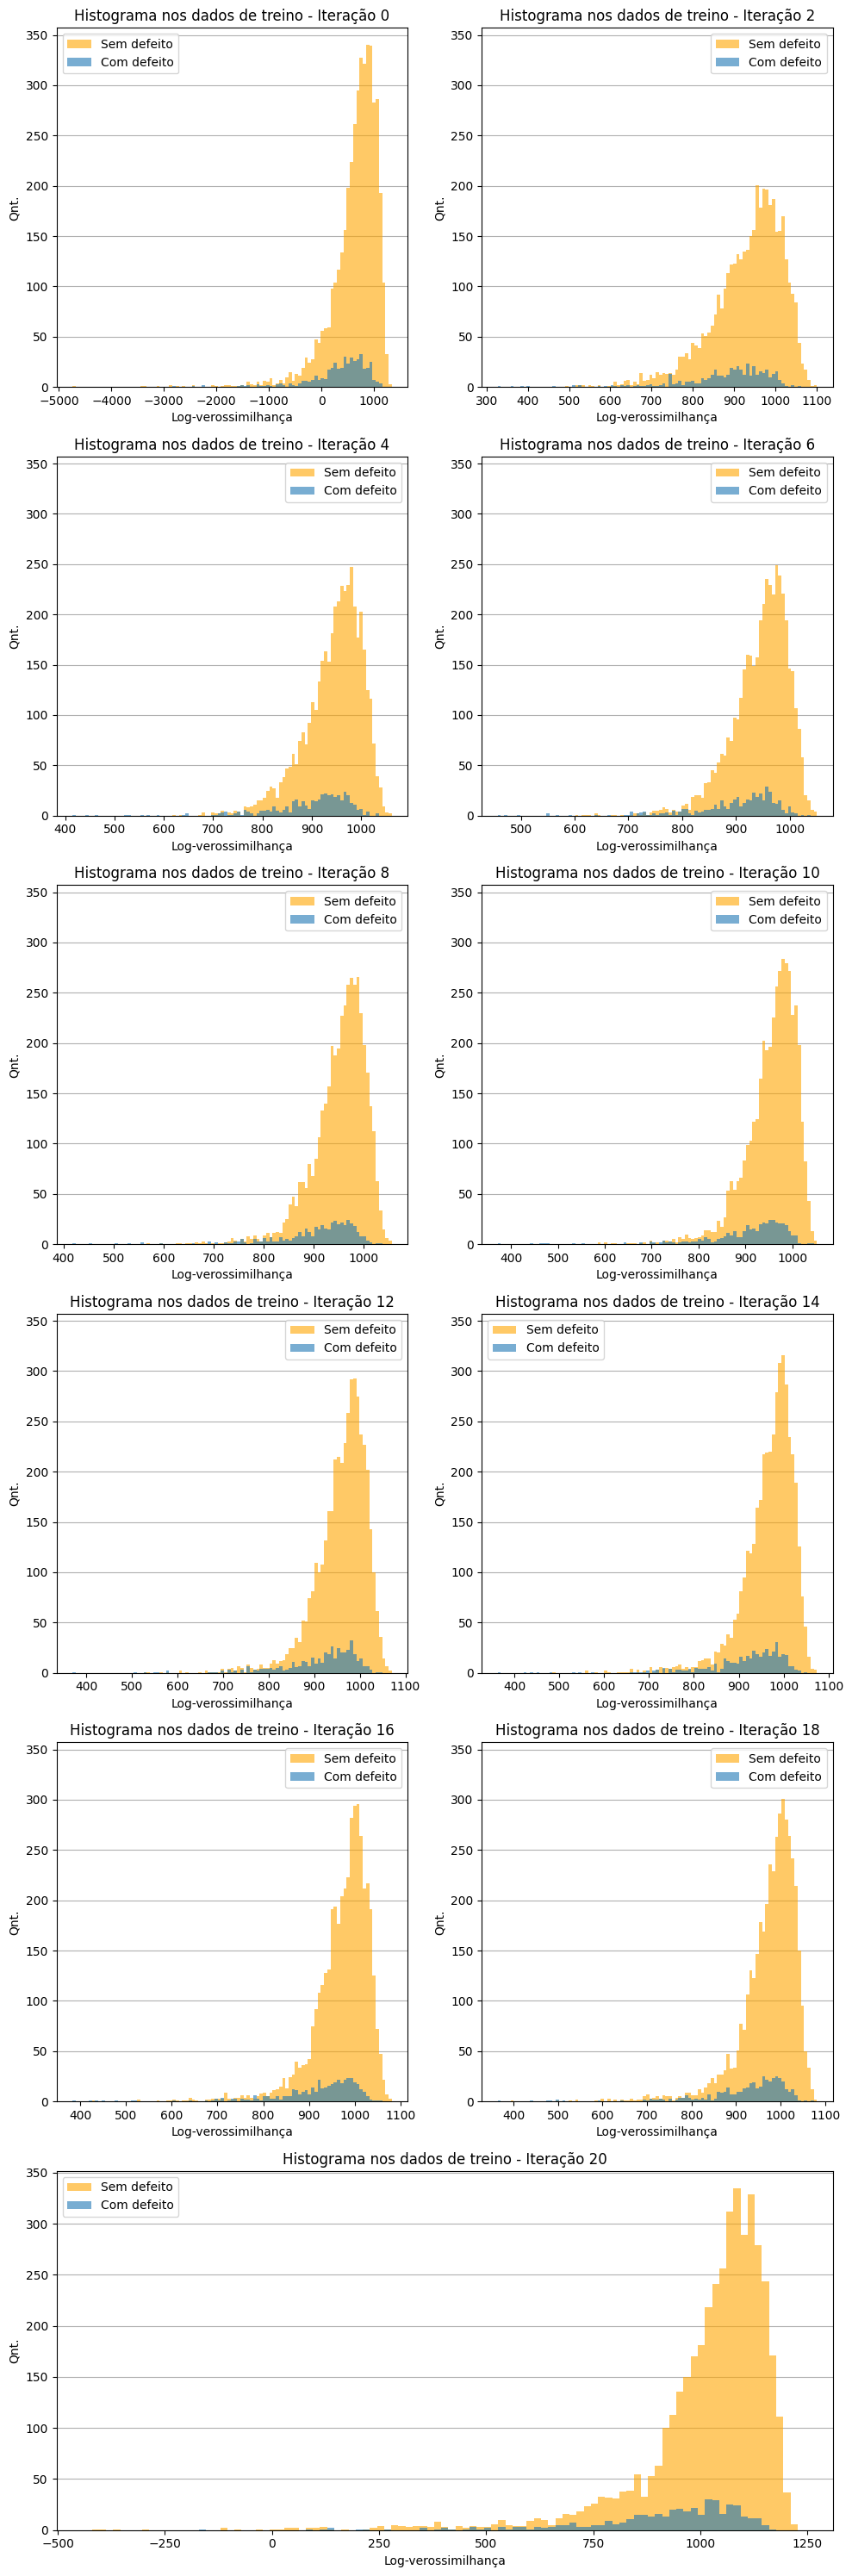

In [12]:
fig, axs = plt.subplots(6, 2, figsize=(10, 30), sharey=True)
gs = axs[-1, 0].get_gridspec()
axs[-1, 0].remove()
axs[-1, 1].remove()
axs[-1, 0] = fig.add_subplot(gs[-1, :])

for iteration in range(0, len(train_evals), 2):
    i, j = divmod(iteration // 2, 2)
    ax = axs[i, j]
    clean_loglikes = train_clean_loglike[iteration]
    defec_loglikes = train_defec_loglike[iteration]
    min_loglike = min(clean_loglikes.min(), defec_loglikes.min())
    max_loglike = max(clean_loglikes.max(), defec_loglikes.max())
    bins = np.linspace(min_loglike, max_loglike, 100)
    ax.hist(clean_loglikes, bins, alpha=0.6, label='Sem defeito', color='orange', zorder=2)
    ax.hist(defec_loglikes, bins, alpha=0.6, label='Com defeito', color='tab:blue', zorder=3)
    ax.set_title(f'Histograma nos dados de treino - Iteração {iteration}')
    ax.set_xlabel('Log-verossimilhança')
    ax.set_ylabel('Qnt.')
    ax.yaxis.set_tick_params(labelbottom=True)
    ax.legend()
    ax.grid(axis='y')

plt.tight_layout()
plt.show()

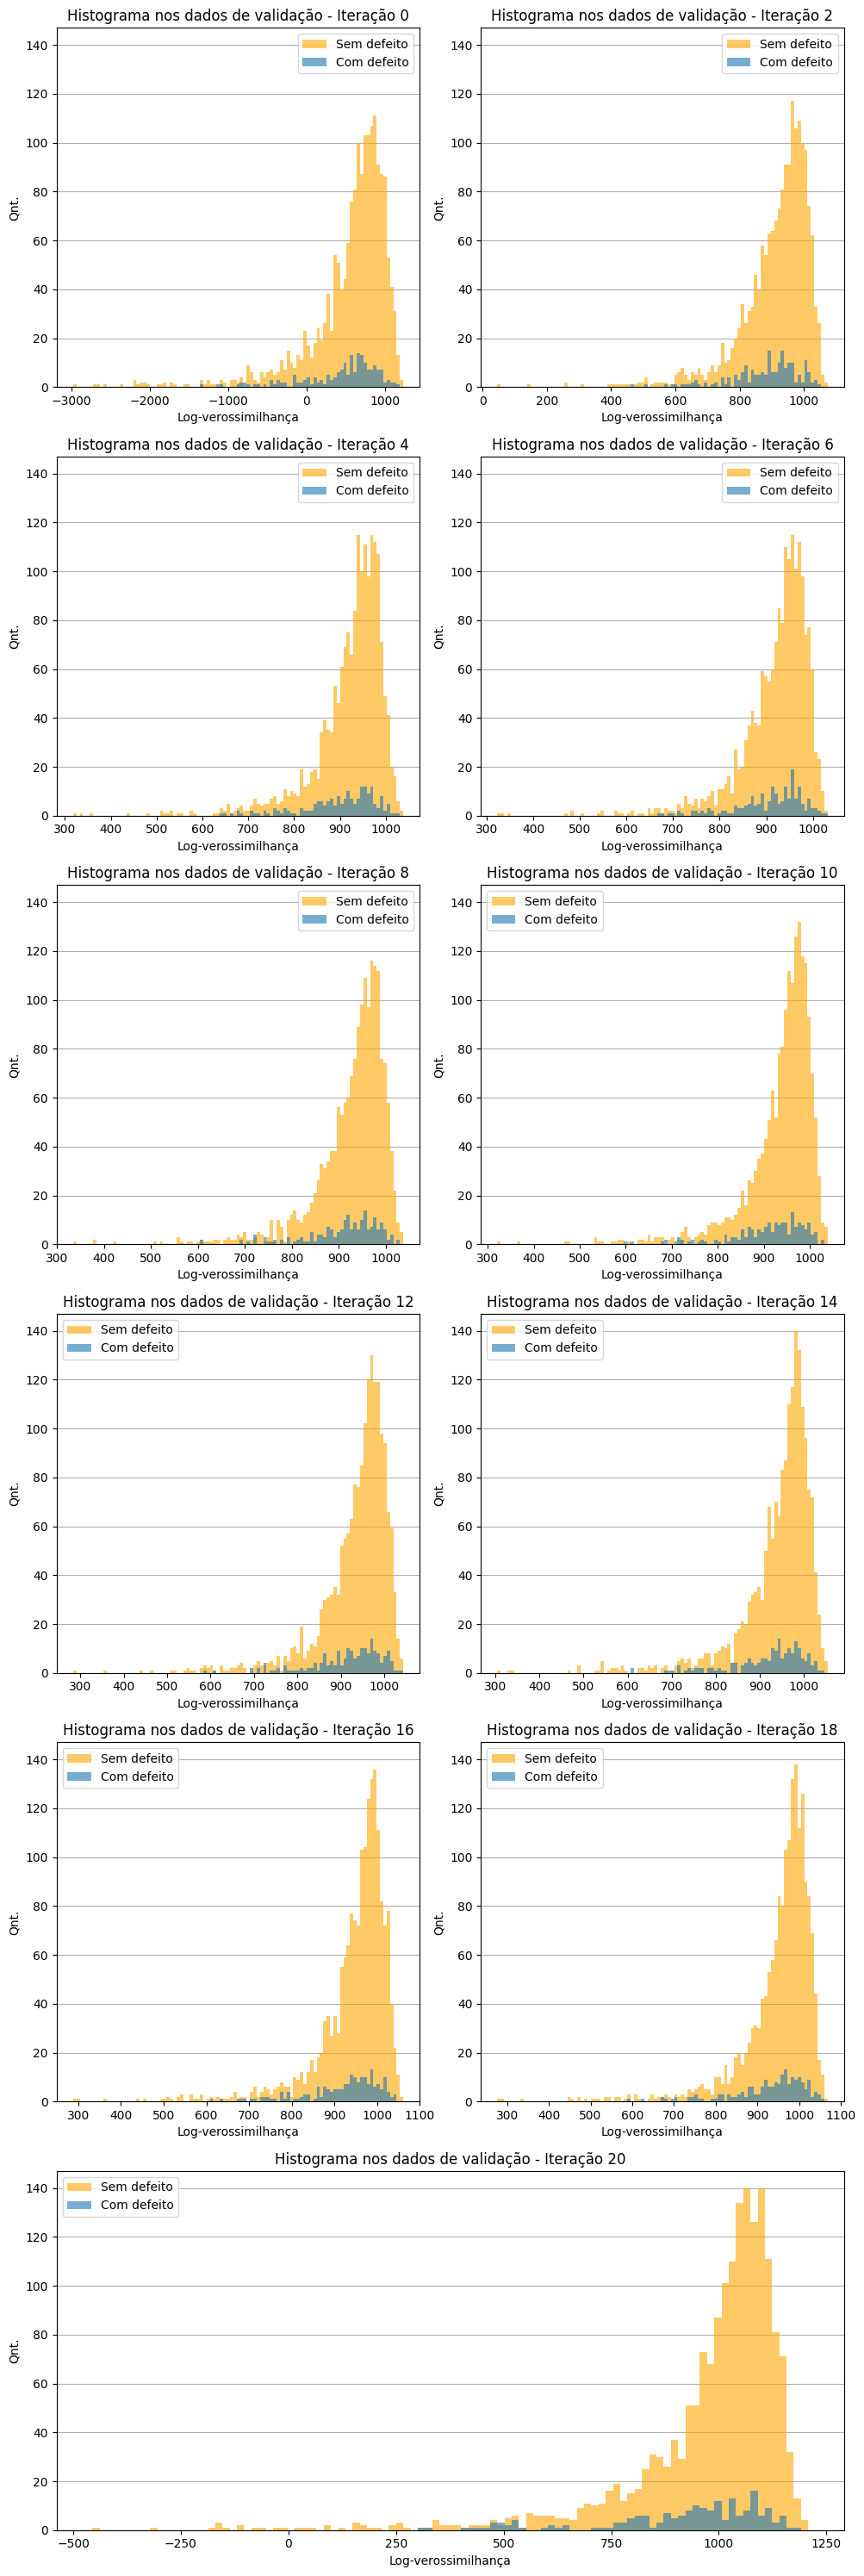

In [13]:
fig, axs = plt.subplots(6, 2, figsize=(10, 30), sharey=True)
gs = axs[-1, 0].get_gridspec()
axs[-1, 0].remove()
axs[-1, 1].remove()
axs[-1, 0] = fig.add_subplot(gs[-1, :])

for iteration in range(0, len(valid_evals), 2):
    i, j = divmod(iteration // 2, 2)
    ax = axs[i, j]
    clean_loglikes = valid_clean_loglike[iteration]
    defec_loglikes = valid_defec_loglike[iteration]
    min_loglike = min(clean_loglikes.min(), defec_loglikes.min())
    max_loglike = max(clean_loglikes.max(), defec_loglikes.max())
    bins = np.linspace(min_loglike, max_loglike, 100)
    ax.hist(clean_loglikes, bins, alpha=0.6, label='Sem defeito', color='orange', zorder=2)
    ax.hist(defec_loglikes, bins, alpha=0.6, label='Com defeito', color='tab:blue', zorder=3)
    ax.set_title(f'Histograma nos dados de validação - Iteração {iteration}')
    ax.set_xlabel('Log-verossimilhança')
    ax.set_ylabel('Qnt.')
    ax.yaxis.set_tick_params(labelbottom=True)
    ax.legend()
    ax.grid(axis='y')

plt.tight_layout()
plt.show()

### Curvas ROC

A cada iteração, novas estimações de densidade são obtidas. Outra forma de avaliar a qualidade da estimação da distribuição marginal $p_{limpas}(x)$ é analisando a curva ROC obtida a partir dos rótulos e dos valores de logpdf da distribuição marginal para cada imagem no conjunto de validação.

Uma vez que a curva ROC espera pontuações maiores para a classe alvo (anomalias, ou seja, imagens com defeitos), em vez da pontuação ser $\log{p_{limpas}(x_{vi})}$ (onde $x_{vi}$ é a i-ésima imagem do conjunto de validação) ela será a negativa desse valor.

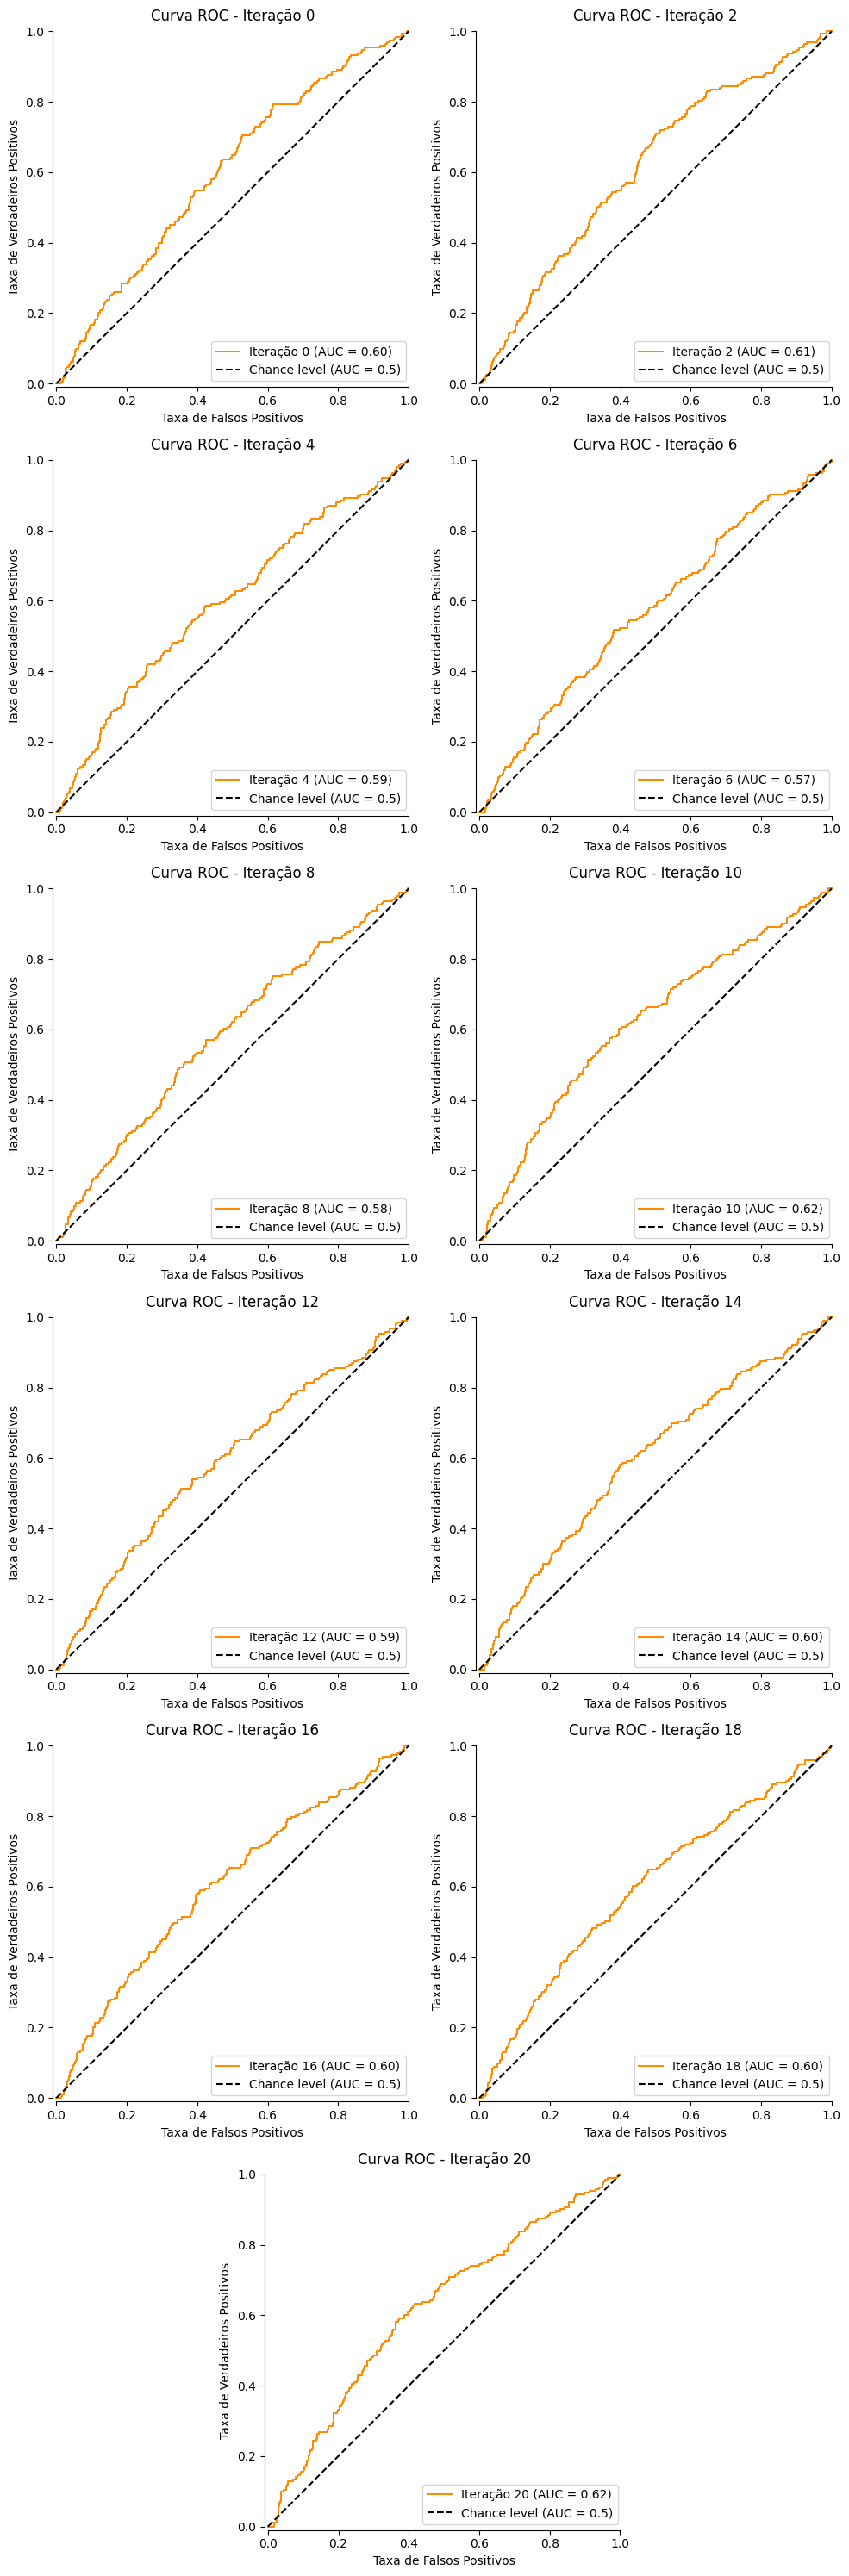

In [14]:
fig, axs = plt.subplots(6, 2, figsize=(10, 30))
gs = axs[-1, 0].get_gridspec()
axs[-1, 0].remove()
axs[-1, 1].remove()
axs[-1, 0] = fig.add_subplot(gs[-1, :])

for iteration in range(0, len(valid_evals), 2):
    i, j = divmod(iteration // 2, 2)
    ax = axs[i, j]
    display = RocCurveDisplay.from_predictions(
        valid_evals[iteration][:, -2],
        -valid_evals[iteration][:, -1],
        name=f'Iteração {iteration}',
        curve_kwargs=dict(color="darkorange"),
        plot_chance_level=True,
        despine=True,
        ax=axs[i, j],
    )
    display.ax_.set(
        title=f'Curva ROC - Iteração {iteration}',
        xlabel='Taxa de Falsos Positivos',
        ylabel='Taxa de Verdadeiros Positivos',
    )

plt.tight_layout()
plt.show()

### Matrizes de confusão

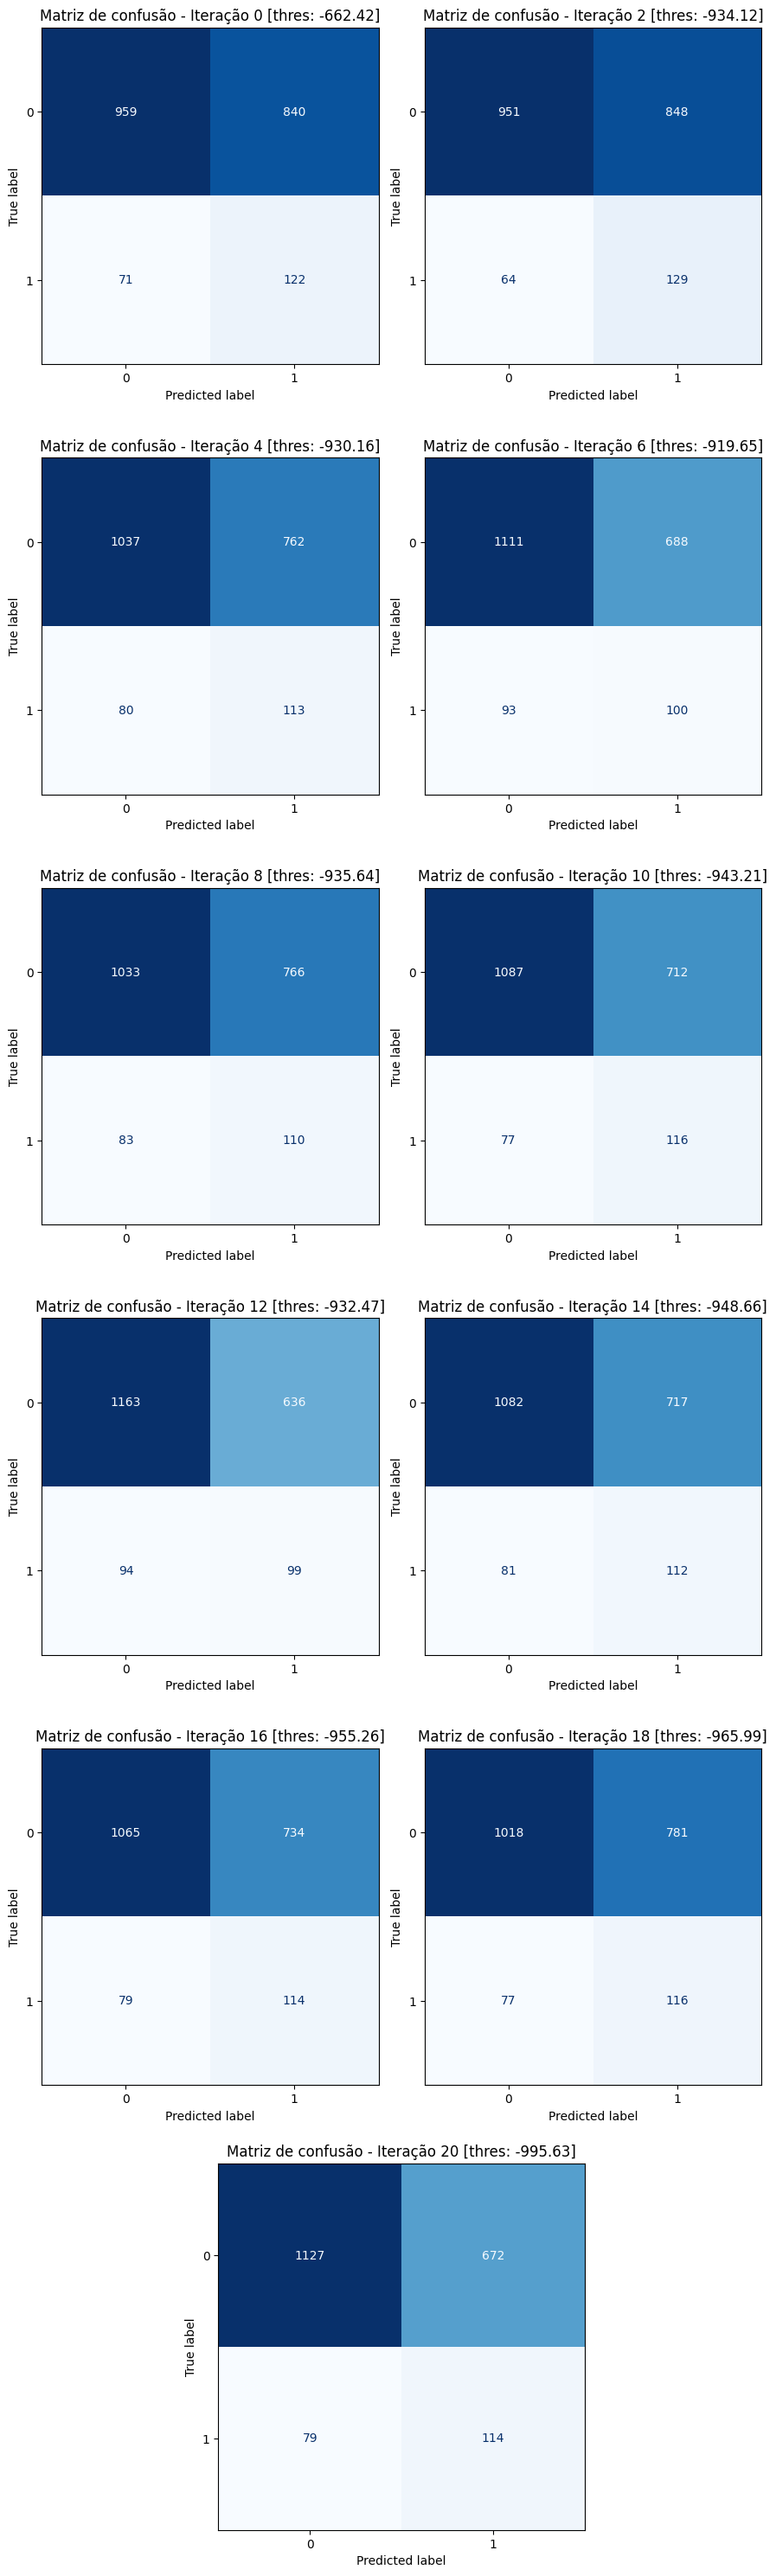

In [15]:
fig, axs = plt.subplots(6, 2, figsize=(9, 30))
gs = axs[-1, 0].get_gridspec()
axs[-1, 0].remove()
axs[-1, 1].remove()
axs[-1, 0] = fig.add_subplot(gs[-1, :])

thresholds_per_iteration = []
for iteration in range(0, len(valid_evals), 2):
    i, j = divmod(iteration // 2, 2)
    ax = axs[i, j]
    tns, fps, fns, tps, thresholds = confusion_matrix_at_thresholds(
        y_true=valid_evals[iteration][:, -2],
        y_score=-valid_evals[iteration][:, -1],
    )
    tpr = tps / (tps + fns)
    fpr = fps / (fps + tns)
    best_thres_idx = np.argmin(fpr ** 2 + (1 - tpr) ** 2)
    # best_threshold_index = np.argmax(tpr - fpr)
    confusion_matrix = np.array(
        [[tns[best_thres_idx], fps[best_thres_idx]],
         [fns[best_thres_idx], tps[best_thres_idx]]],
        dtype=int,
    )
    display = ConfusionMatrixDisplay(confusion_matrix)
    display.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'Matriz de confusão - Iteração {iteration} [thres: {thresholds[best_thres_idx]:.2f}]')
    thresholds_per_iteration.append(thresholds[best_thres_idx])

plt.tight_layout()
plt.show()

### Salvar detecções para inspeção

In [16]:
# from shutil import copy

# last_iter_threshould = thresholds_per_iteration[-1]
# last_eval = valid_evals[-1]
# predictions = -last_eval[:, -1] >= last_iter_threshould
# targets = last_eval[:, -2].astype(bool)

# tps = np.nonzero(targets & predictions)[0]
# tns = np.nonzero(~targets & ~predictions)[0]
# fps = np.nonzero(predictions & ~targets)[0]
# fns = np.nonzero(~predictions & targets)[0]

# with (dataset_dir / 'pav_features/valid_split_image_paths.txt').open('r') as f:
#     valid_image_paths = f.read().splitlines()

# for label, idxs in (('tps', tps), ('tns', tns), ('fps', fps), ('fns', fns)):
#     save_dir = results_dir / 'detec' / label
#     save_dir.mkdir(parents=True, exist_ok=True)
#     for idx in idxs:
#         img_path = valid_image_paths[idx]
#         copy(img_path, save_dir)